<a href="https://colab.research.google.com/github/aricore87/aphelion/blob/main/Task_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


Consider a binary pair of stars of masses 5 solar mass and 3 solar mass.
They revolve around the common centre of mass in XY plane with the period of 8.64 × 10^5 seconds (10 earth-days).
Determine the distance between them.
Their orbit is eccentric orbit with eccentricity of 0.20 and major axis along X axis.

Simulate this situation.
1) Plot the orbit with fixed centre of mass.
2) Plot orbit of secondary (low mass star) with respect to primary.

Assume you are now observing them along Y axis from a distance of 10 pc.
3) Plot the graph of radial velocity of both stars as function of time.
4) Repeat 1), 2) and 3) for eccentricity of 0.30, 0.50, 0.70

Now assume that you are observing the stars along X axis.
5) Repeat 1), 2), 3) and 4).

If your line of sight is along 30° with X axis and 40° with z - axis, repeat 1), 2), 3) and 4).

Calculated Separation (Semi-major axis 'a'): 0.1817 AU


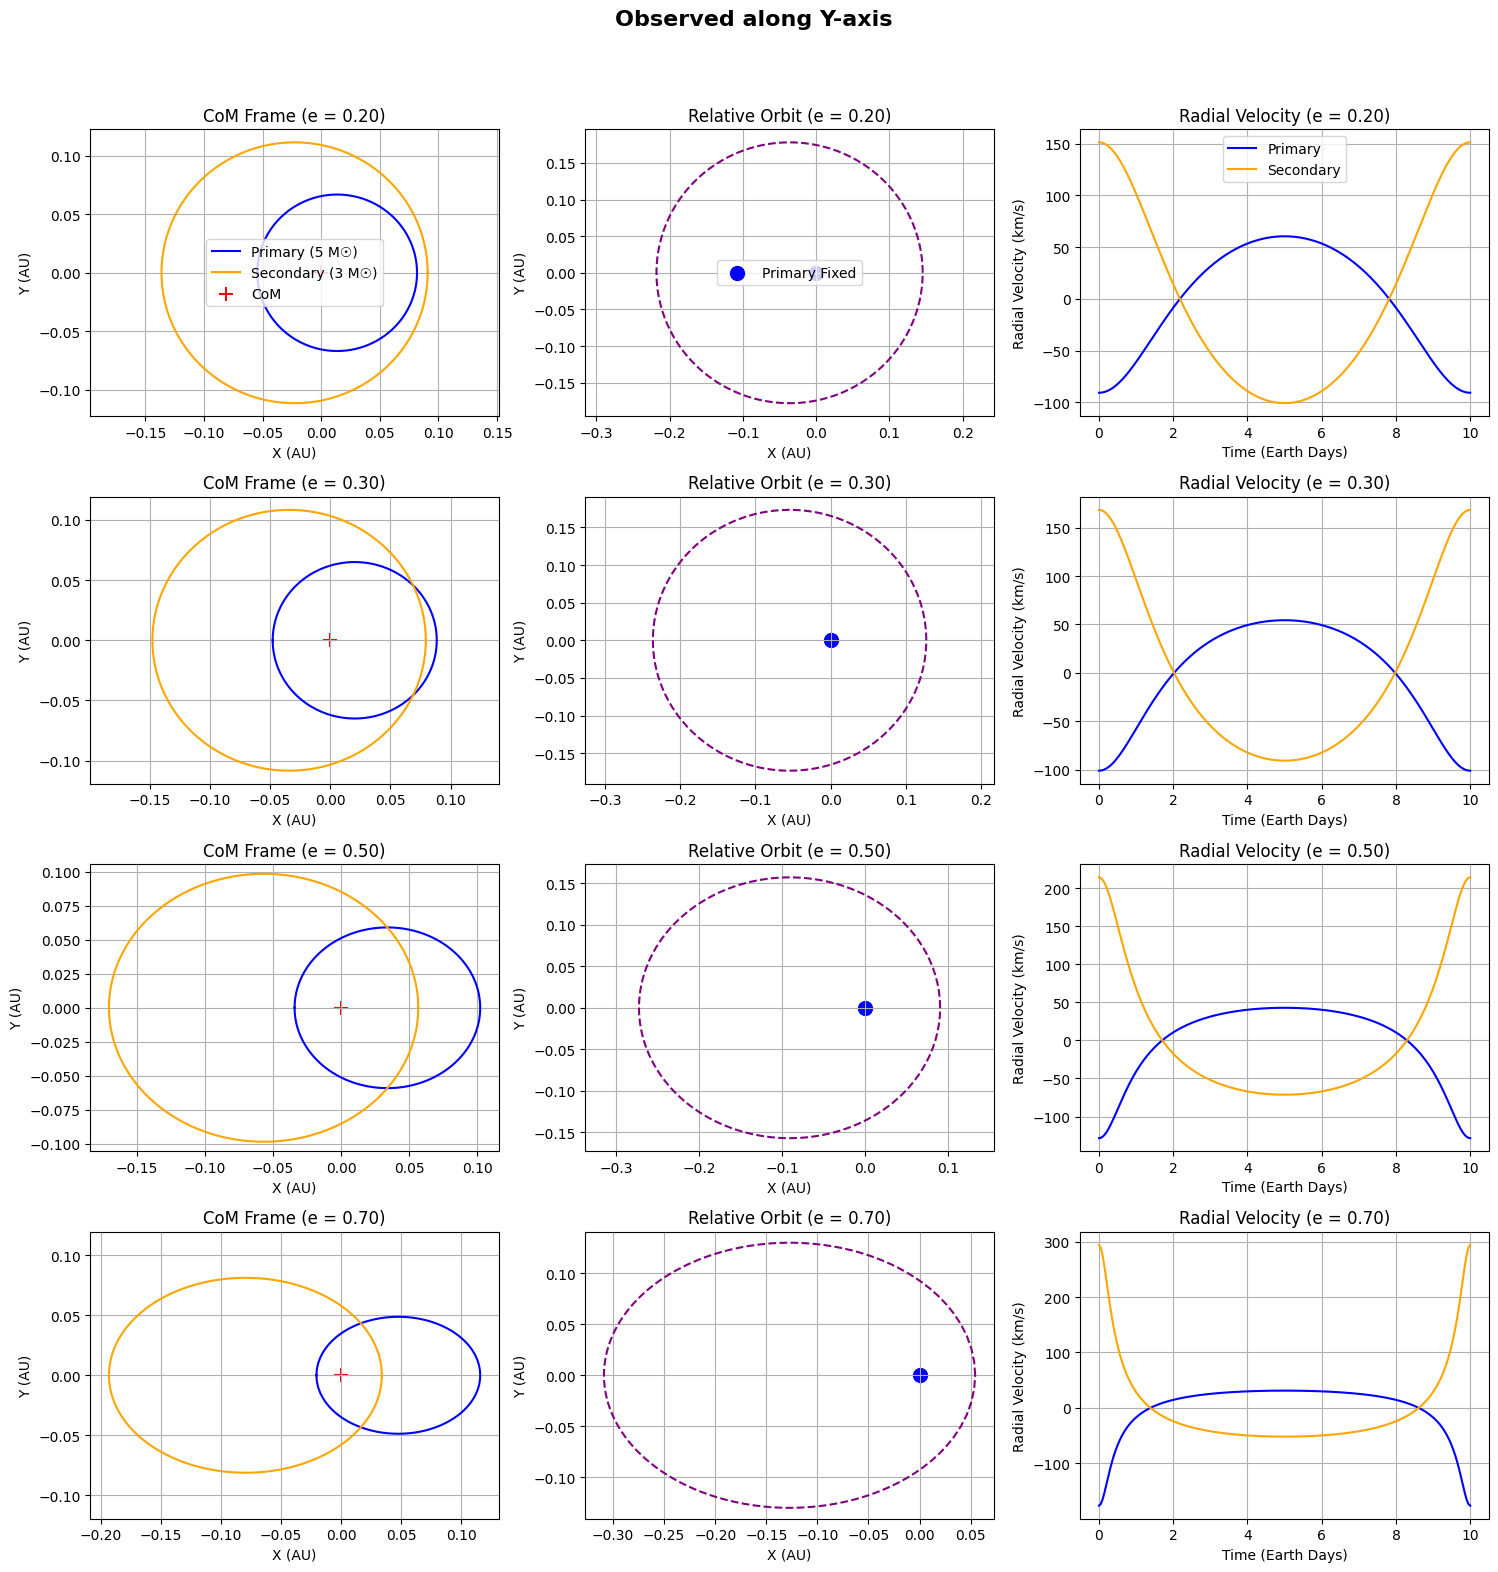

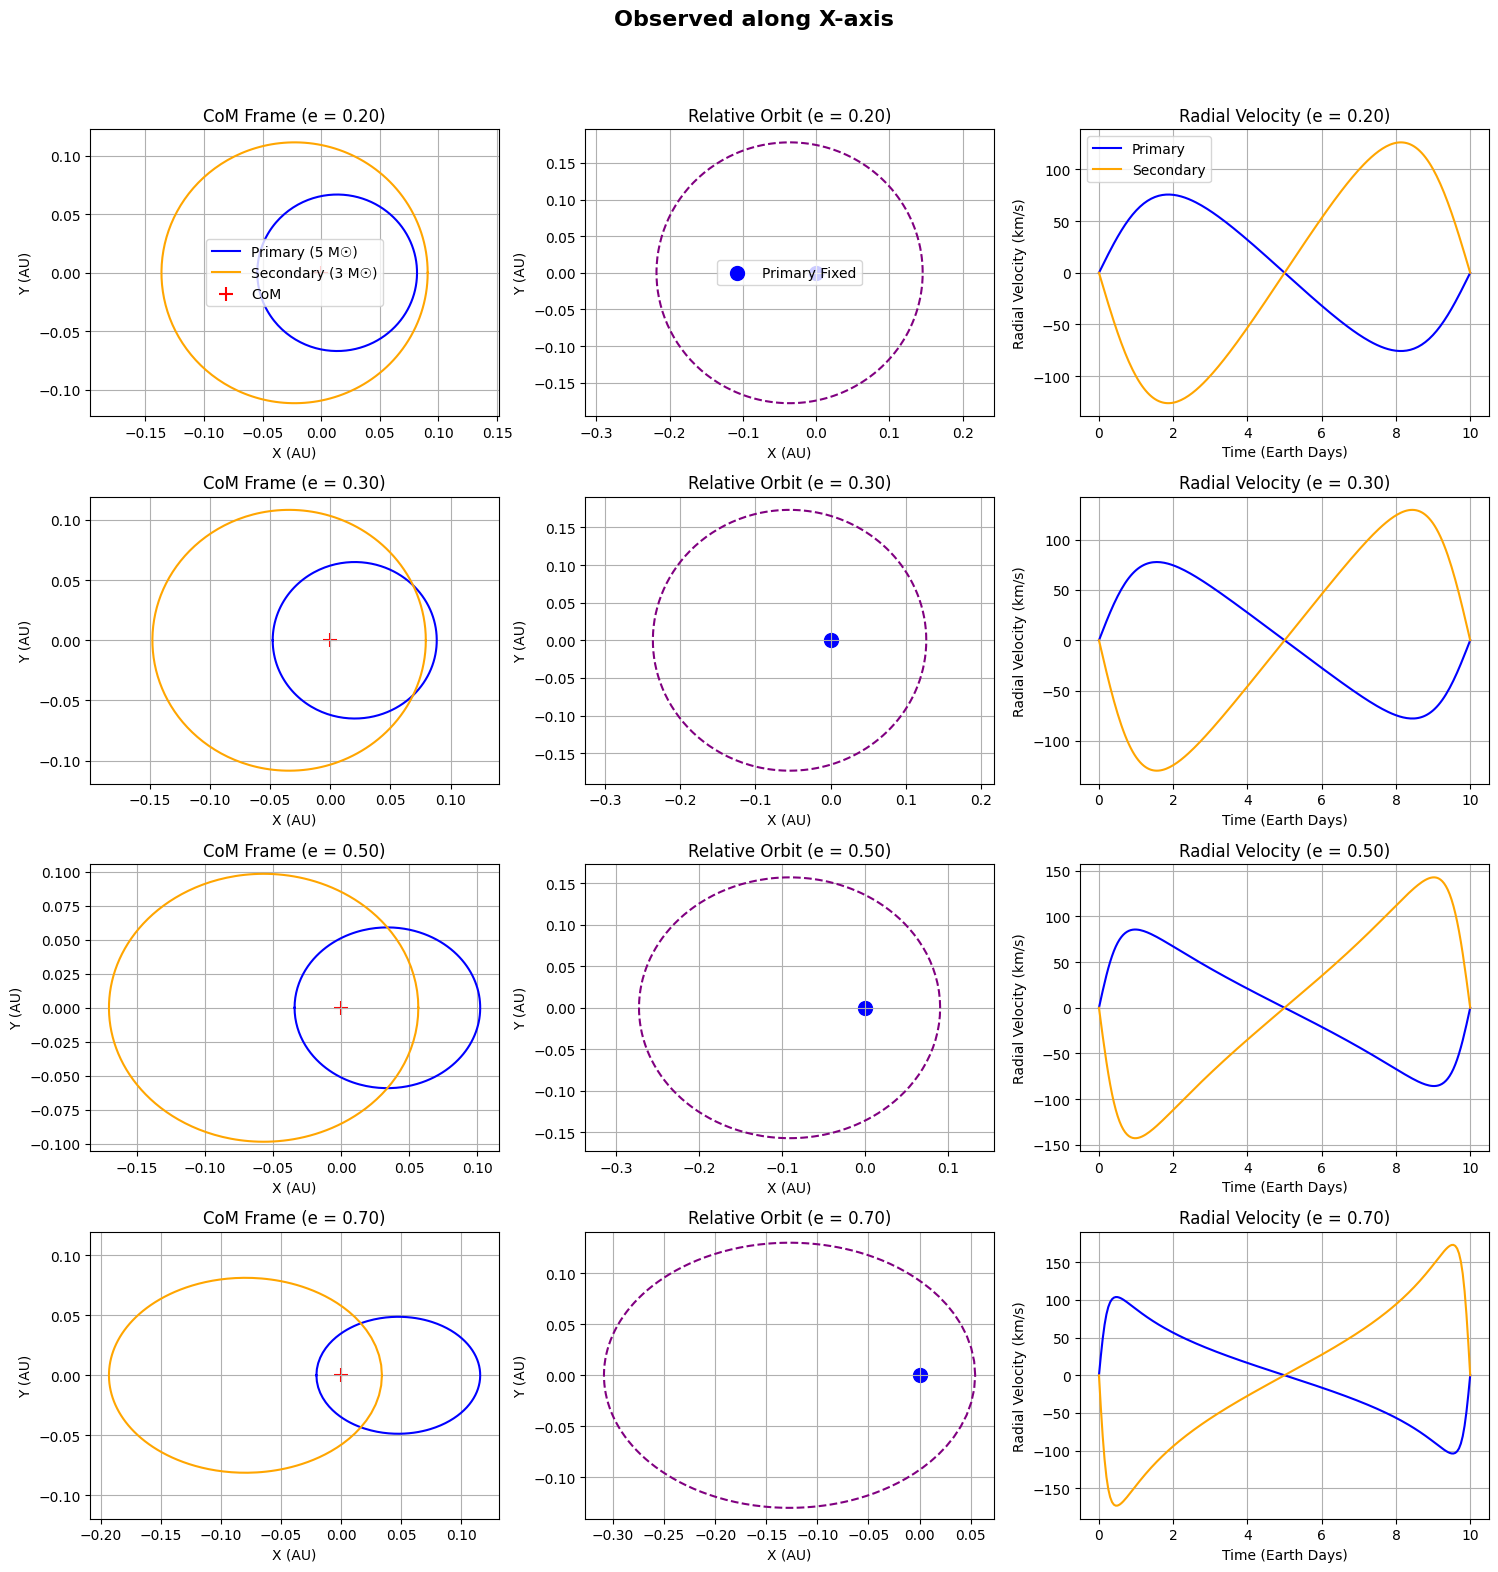

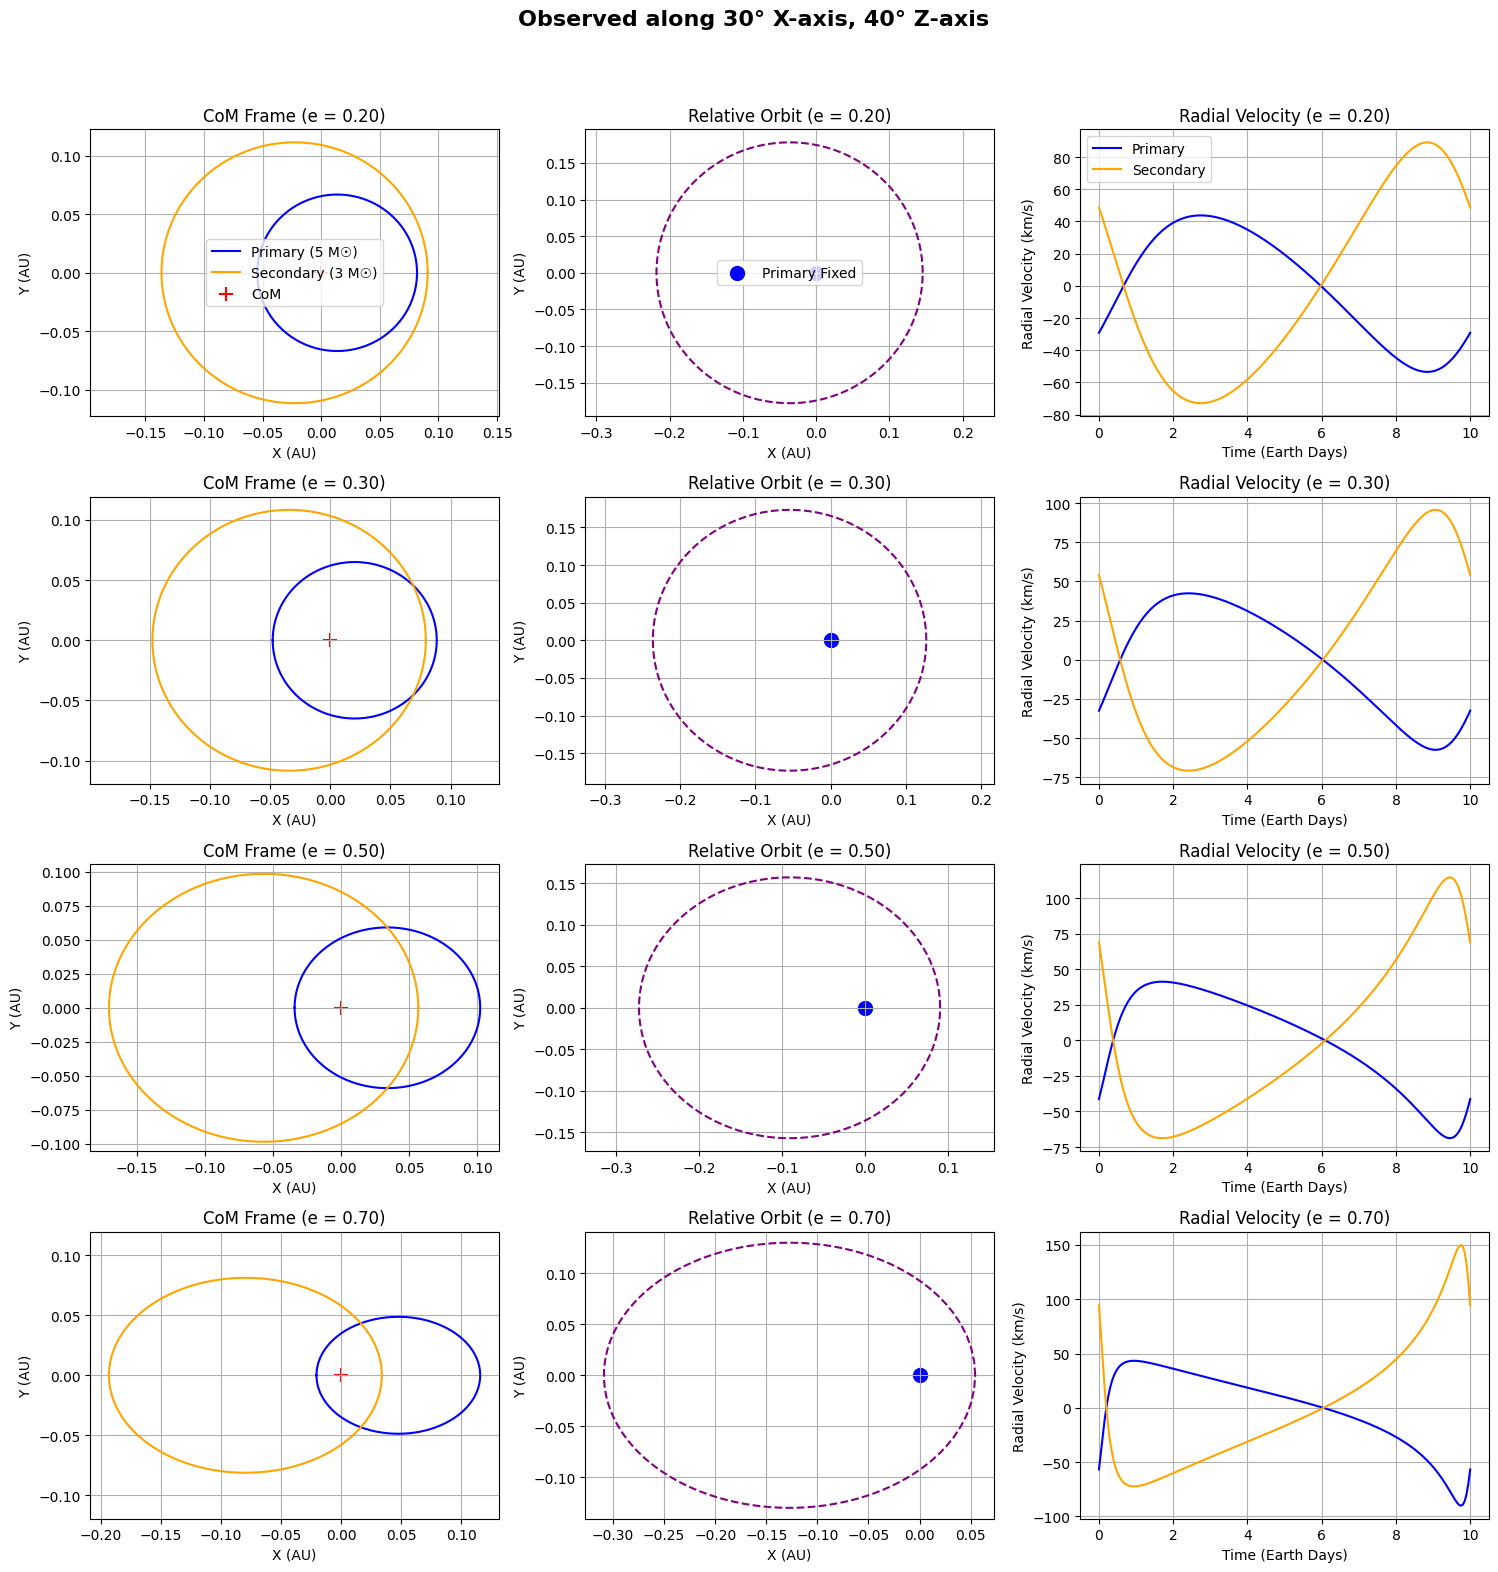

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# CONSTANTS
G = 6.67430e-11          # m^3 kg^-1 s^-2
M_sun = 1.989e30         # kg
AU = 1.496e11            # meters (for nicer plot labels)

M1 = 5.0 * M_sun
M2 = 3.0 * M_sun
T = 8.64e5               # seconds (10 days)

# Calculate semi-major axis (a) using Kepler's 3rd Law
a = (((G * (M1 + M2) * T**2) / (4 * np.pi**2))**(1/3))
print(f"Calculated Separation (Semi-major axis 'a'): {a / AU:.4f} AU")

# Time array for one full orbit
times = np.linspace(0, T/4, 200)

# Kepler Solver for Eccentric Anomaly (E)
def solve_kepler(M, e):
    E = M.copy()  # Initial guess
    for _ in range(10):  # Newton-Raphson iteration
        E = E - (E - e * np.sin(E) - M) / (1 - e * np.cos(E))
    return E

# Function to compute positions and velocities over time
def compute_orbit(e):
    # Mean Anomaly
    M = (2 * np.pi / T) * times
    # Eccentric Anomaly
    E = solve_kepler(M, e)

    # True Anomaly (theta)
    theta = 2 * np.arctan2(np.sqrt(1 + e) * np.sin(E / 2), np.sqrt(1 - e) * np.cos(E / 2))

    # Distance r dynamically changing with theta
    r = a * (1 - e**2) / (1 + e * np.cos(theta))

    # Positions of Secondary relative to Primary
    x_rel = r * np.cos(theta)
    y_rel = r * np.sin(theta)
    z_rel = np.zeros_like(x_rel)

    # Positions relative to Center of Mass (CoM)
    x1 = -(M2 / (M1 + M2)) * x_rel
    y1 = -(M2 / (M1 + M2)) * y_rel
    x2 = (M1 / (M1 + M2)) * x_rel
    y2 = (M1 / (M1 + M2)) * y_rel

    # Velocities relative to CoM
    v_factor = np.sqrt(G * (M1 + M2) / (a * (1 - e**2)))
    vx_rel = -v_factor * np.sin(theta)
    vy_rel = v_factor * (e + np.cos(theta))

    vx1 = -(M2 / (M1 + M2)) * vx_rel
    vy1 = -(M2 / (M1 + M2)) * vy_rel
    vx2 = (M1 / (M1 + M2)) * vx_rel
    vy2 = (M1 / (M1 + M2)) * vy_rel

    pos1 = np.array([x1, y1, z_rel])
    pos2 = np.array([x2, y2, z_rel])
    pos_rel = np.array([x_rel, y_rel, z_rel])

    vel1 = np.array([vx1, vy1, np.zeros_like(vx1)])
    vel2 = np.array([vx2, vy2, np.zeros_like(vx2)])

    return pos1, pos2, pos_rel, vel1, vel2

# SIMULATION
eccentricities = [0.20, 0.30, 0.50, 0.70]

# Define Lines of Sight cases
# Format: (Name, Unit Vector hat_n)
los_cases = [
    ("Observed along Y-axis", np.array([0, 1, 0])),
    ("Observed along X-axis", np.array([1, 0, 0])),
    ("Observed along 30° X-axis, 40° Z-axis", np.array([
        np.sin(np.radians(40)) * np.cos(np.radians(30)),
        np.sin(np.radians(40)) * np.sin(np.radians(30)),
        np.cos(np.radians(40))
    ]))
]

# plots for each Line of Sight condition
for los_name, n_hat in los_cases:
    fig, axs = plt.subplots(len(eccentricities), 3, figsize=(15, 4 * len(eccentricities)))
    fig.suptitle(los_name, fontsize=16, fontweight='bold')

    for idx, e in enumerate(eccentricities):
        pos1, pos2, pos_rel, vel1, vel2 = compute_orbit(e)

        # Calculate Radial Velocities (Dot product with line of sight vector)
        vr1 = np.tensordot(n_hat, vel1, axes=(0,0)) / 1000.0  # convert to km/s
        vr2 = np.tensordot(n_hat, vel2, axes=(0,0)) / 1000.0  # convert to km/s

        # Subplot 1: Fixed CoM Orbit
        axs[idx, 0].plot(pos1[0]/AU, pos1[1]/AU, label='Primary (5 M☉)', color='blue')
        axs[idx, 0].plot(pos2[0]/AU, pos2[1]/AU, label='Secondary (3 M☉)', color='orange')
        axs[idx, 0].scatter(0, 0, color='red', marker='+', s=100, label='CoM')
        axs[idx, 0].set_title(f'CoM Frame (e = {e:.2f})')
        axs[idx, 0].set_xlabel('X (AU)')
        axs[idx, 0].set_ylabel('Y (AU)')
        axs[idx, 0].axis('equal')
        axs[idx, 0].grid(True)
        if idx == 0: axs[idx, 0].legend()

        # Subplot 2: Relative Orbit (Secondary around Primary)
        axs[idx, 1].plot(pos_rel[0]/AU, pos_rel[1]/AU, color='purple', linestyle='--')
        axs[idx, 1].scatter(0, 0, color='blue', s=100, label='Primary Fixed')
        axs[idx, 1].set_title(f'Relative Orbit (e = {e:.2f})')
        axs[idx, 1].set_xlabel('X (AU)')
        axs[idx, 1].set_ylabel('Y (AU)')
        axs[idx, 1].axis('equal')
        axs[idx, 1].grid(True)
        if idx == 0: axs[idx, 1].legend()

        # Subplot 3: Radial Velocity Curve
        days = times / (24 * 3600)
        axs[idx, 2].plot(days, vr1, label='Primary', color='blue')
        axs[idx, 2].plot(days, vr2, label='Secondary', color='orange')
        axs[idx, 2].set_title(f'Radial Velocity (e = {e:.2f})')
        axs[idx, 2].set_xlabel('Time (Earth Days)')
        axs[idx, 2].set_ylabel('Radial Velocity (km/s)')
        axs[idx, 2].grid(True)
        if idx == 0: axs[idx, 2].legend()

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()